Importing the Dependencies

In [1]:

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:

# Load dataset
diabetes = pd.read_csv('diabetes.csv')

diabetes.shape


(768, 9)

In [3]:
diabetes.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:

diabetes['Outcome'].unique()

array([1, 0], dtype=int64)

In [5]:

diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### Approach 1

#### Count 0s in each column

In [6]:

print((diabetes[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [7]:

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    diabetes[col] = diabetes[col].replace(0, diabetes[col].median())  
diabetes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


### Approach 2

In [8]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(imputer.fit_transform(diabetes), columns=diabetes.columns)

df_imputed


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,30.5,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,30.5,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,23.0,30.5,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
764,2.0,122.0,70.0,27.0,30.5,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,23.0,30.5,30.1,0.349,47.0,1.0


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(diabetes.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Matrix')
plt.show()


In [9]:

diabetes.shape

(768, 9)

In [10]:
# Separate features and labels

X = diabetes.drop(columns='Outcome', axis=1)

Y = diabetes['Outcome']


In [11]:

X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,30.5,33.6,0.627,50
1,1,85,66,29,30.5,26.6,0.351,31
2,8,183,64,23,30.5,23.3,0.672,32
3,1,89,66,23,94.0,28.1,0.167,21
4,0,137,40,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63
764,2,122,70,27,30.5,36.8,0.340,27
765,5,121,72,23,112.0,26.2,0.245,30
766,1,126,60,23,30.5,30.1,0.349,47


In [12]:

Y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [13]:

# Scale using StandardScaler and preserve column names

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


In [14]:

X_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.831114,-0.608201,0.167240,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,0.180566,-0.608201,-0.851551,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.469981,-0.608201,-1.331838,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.469981,-0.006185,-0.633239,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.831114,0.695378,1.549885,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.679069,0.298896,2.240633,0.809145,0.065361,-0.908682,2.532136
764,-0.547919,0.011301,-0.197433,-0.036283,-0.608201,0.632973,-0.398282,-0.531023
765,0.342981,-0.021574,-0.031990,-0.469981,0.164466,-0.909768,-0.685193,-0.275760
766,-0.844885,0.142800,-1.024647,-0.469981,-0.608201,-0.342155,-0.371101,1.170732


In [15]:

# Train-test split

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, stratify=Y, random_state=2)


In [ ]:

X_train.shape

In [16]:
# Train GaussianNB on DataFrame

classifier = GaussianNB()

classifier.fit(X_train, Y_train)


GaussianNB()

In [17]:
# Model Evaluation

X_train_pred = classifier.predict(X_train)

train_accuracy = accuracy_score(Y_train, X_train_pred)
print("Training Accuracy:", train_accuracy*100)

Training Accuracy: 75.2442996742671


In [18]:

X_test_pred = classifier.predict(X_test)

test_accuracy = accuracy_score(Y_test, X_test_pred)
print("Testing Accuracy:", test_accuracy*100)

Testing Accuracy: 72.72727272727273


In [19]:

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, X_test_pred))
print("\nClassification Report:\n", classification_report(Y_test, X_test_pred))



Confusion Matrix:
 [[86 14]
 [28 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       100
           1       0.65      0.48      0.55        54

    accuracy                           0.73       154
   macro avg       0.70      0.67      0.68       154
weighted avg       0.72      0.73      0.72       154



#### Unk data

| Index | Feature            | Value |
| ----- | ------------------ | ----- |
| 0     | Pregnancies        | 5     |
| 1     | Glucose            | 166   |
| 2     | BloodPressure      | 72    |
| 3     | SkinThickness      | 19    |
| 4     | Insulin            | 175   |
| 5     | BMI                | 25.8  |
| 6     | DiabetesPedigreeFn | 0.587 |
| 7     | Age                | 51    |


In [20]:

input_data = (5, 166, 72, 19, 175, 25.8, 0.587, 51)

feature_names = X.columns.tolist()
input_df = pd.DataFrame([input_data], columns=feature_names)

input_scaled_df = pd.DataFrame(scaler.transform(input_df), columns=feature_names)
input_scaled_df 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.342981,1.457791,-0.03199,-0.903679,0.761742,-0.967984,0.347687,1.511083


In [21]:
# Predict

prediction = classifier.predict(input_scaled_df)
prediction


array([1], dtype=int64)

In [22]:

probability = classifier.predict_proba(input_scaled_df)[0][1] * 100
probability


63.56102702346772

In [23]:

print("\nPrediction:", prediction)

if prediction[0] == 0:
    print("The person is **not diabetic**")
else:
    print("The person is **diabetic**")

print(f"Probability of being diabetic: {probability:.2f}%")



Prediction: [1]
The person is **diabetic**
Probability of being diabetic: 63.56%


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


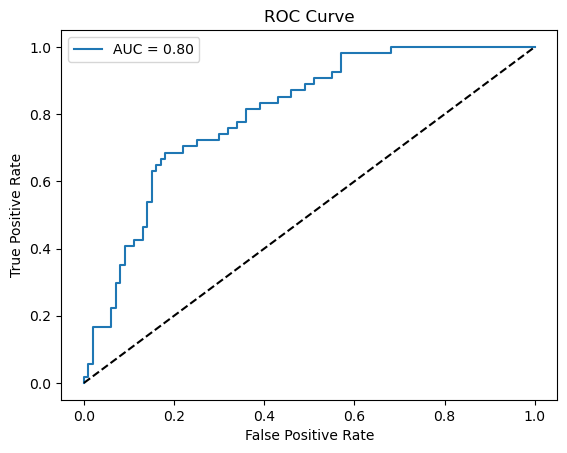

In [25]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(Y_test, classifier.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

| Method                   | Use When                      | Pros                          | Cons                           |
| ------------------------ | ----------------------------- | ----------------------------- | ------------------------------ |
| Replace with mean/median | Most common method, quick fix | Simple, fast                  | May distort distribution       |
| KNN Imputer              | Enough data, want accuracy    | Smarter, uses neighbor values | Slower, needs tuning           |